Import required libraries

In [ ]:
#pip install opencv-contrib-python


   ---------------------------------------- 0.0/46.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/46.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/46.5 MB ? eta -:--:--
    --------------------------------------- 0.8/46.5 MB 1.6 MB/s eta 0:00:29
    --------------------------------------- 1.0/46.5 MB 1.5 MB/s eta 0:00:31
   - -------------------------------------- 1.3/46.5 MB 1.4 MB/s eta 0:00:32
   - -------------------------------------- 1.6/46.5 MB 1.5 MB/s eta 0:00:30
   - -------------------------------------- 1.8/46.5 MB 1.5 MB/s eta 0:00:30
   -- ------------------------------------- 2.4/46.5 MB 1.5 MB/s eta 0:00:30
   -- ------------------------------------- 2.6/46.5 MB 1.5 MB/s eta 0:00:29
   -- ------------------------------------- 3.1/46.5 MB 1.6 MB/s eta 0:00:27
   --- ------------------------------------ 3.7/46.5 MB 1.7 MB/s eta 0:00:26
   --- ------------------------------------ 3.9/46.5 MB 1.7 MB/s eta 0:00:26
   --- -------------

ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'c:\\Users\\chinm\\anaconda3\\Lib\\site-packages\\cv2\\cv2.pyd'
Consider using the `--user` option or check the permissions.



In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

Load Dataset Path

In [7]:
data_path="E:\Cancer_Detection_Dataset_PROJECT\dataset\Training"

Read and Preprocess Images

In [8]:
x = []
y = []

for category in os.listdir(data_path):
    category_path = os.path.join(data_path, category)
    
    if os.path.isdir(category_path):
        for file in os.listdir(category_path):
            img_path = os.path.join(category_path, file)
            
            if img_path.endswith(('.jpg', '.png', '.jpeg')):
                img = cv2.imread(img_path)
                img = cv2.resize(img, (128, 128))
                img = img / 255.0
                
                x.append(img)
                y.append(category)

x = np.array(x)
y = np.array(y)

print("Images shape:", x.shape)
print("Labels shape:", y.shape)


Images shape: (5600, 128, 128, 3)
Labels shape: (5600,)


Encode Labels

In [9]:
le = LabelEncoder()
y = le.fit_transform(y)
y = to_categorical(y)


Train-Test Split

In [10]:
xtrain, xtest, ytrain, ytest = train_test_split(
    x, y, test_size=0.2, random_state=42
)


In [11]:
print(len(xtrain),len(ytrain))
print(len(xtest),len(ytest))

4480 4480
1120 1120


Build CNN Model

In [15]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(MaxPool2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPool2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPool2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(len(le.classes_), activation='softmax'))


In [16]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Compile Model

In [17]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


Train Model

In [18]:
history = model.fit(
    xtrain, ytrain,
    epochs=20,
    batch_size=16,
    validation_data=(xtest, ytest)
)


Epoch 1/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 73s 241ms/step - accuracy: 0.6757 - loss: 0.7815 - val_accuracy: 0.7812 - val_loss: 0.4786
Epoch 2/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 45s 159ms/step - accuracy: 0.8116 - loss: 0.4771 - val_accuracy: 0.8134 - val_loss: 0.4182
Epoch 3/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 65s 232ms/step - accuracy: 0.8656 - loss: 0.3555 - val_accuracy: 0.9000 - val_loss: 0.2769
Epoch 4/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 77s 275ms/step - accuracy: 0.8933 - loss: 0.2726 - val_accuracy: 0.9071 - val_loss: 0.2724
Epoch 5/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 73s 259ms/step - accuracy: 0.9261 - loss: 0.2052 - val_accuracy: 0.9161 - val_loss: 0.2473
Epoch 6/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 82s 292ms/step - accuracy: 0.9417 - loss: 0.1530 - val_accuracy: 0.9295 - val_loss: 0.2105
Epoch 7/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 50s 178ms/step - accuracy: 0.9576 - loss: 0.1192 - val_accuracy: 0.9268 - val_loss: 0.2154
Epoch 8/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 78s 163ms/step - accuracy: 0.9652 - loss: 0

In [19]:
# Evaluate model on test data
test_loss, test_accuracy = model.evaluate(xtest, ytest)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)


35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.9473 - loss: 0.2812
Test Loss: 0.2812063694000244
Test Accuracy: 0.9473214149475098
Test Accuracy (%): 94.73214149475098


In [20]:
# Predict on test set
y_pred = model.predict(xtest)

# Convert one-hot to class index
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(ytest, axis=1)

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

print("Confusion Matrix:\n", cm)


35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step
Confusion Matrix:
 [[296   4   0   0]
 [ 29 251   8   0]
 [  2  11 244   0]
 [  1   4   0 270]]


In [21]:
from sklearn.metrics import classification_report

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=le.classes_))



Classification Report:

              precision    recall  f1-score   support

      glioma       0.90      0.99      0.94       300
  meningioma       0.93      0.87      0.90       288
     notumor       0.97      0.95      0.96       257
   pituitary       1.00      0.98      0.99       275

    accuracy                           0.95      1120
   macro avg       0.95      0.95      0.95      1120
weighted avg       0.95      0.95      0.95      1120



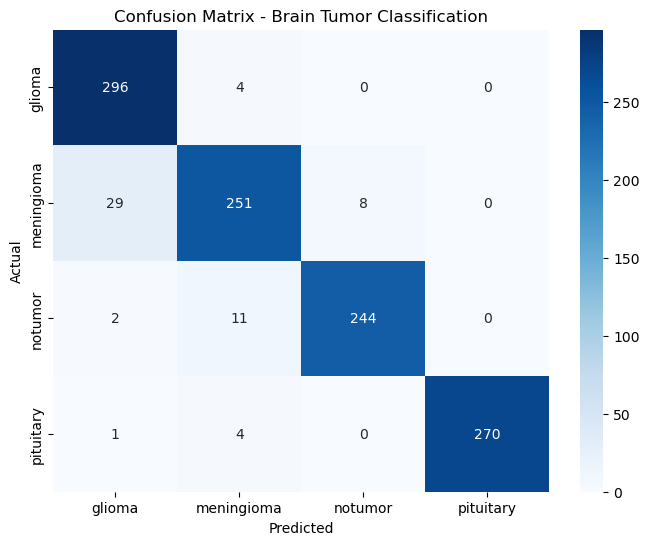

In [22]:
plt.figure(figsize=(8,6))
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Brain Tumor Classification")
plt.show()


Save Model

In [23]:
model.save("brain_tumor_model.h5")
print("Model Saved Successfully!")


Model Saved Successfully!


In [24]:
test_data1="E:\Cancer_Detection_Dataset_PROJECT\dataset\Testing\meningioma\Te-aug-me_2.jpg"

In [25]:
from tensorflow.keras.models import load_model

# Load model
model = load_model("brain_tumor_model.h5")

In [26]:
img=cv2.imread(test_data1)                 # Read Image
img = cv2.resize(img, (128,128))           # Resize to model input size
img = img / 255.0                          # Normalize
img = img.reshape(1,128,128,3)             # Add batch dimension


In [27]:
prediction=model.predict(img)
prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step


array([[1.6773477e-01, 8.3224273e-01, 2.2485781e-05, 5.0363597e-10]],
      dtype=float32)

In [28]:
#Get class index
pred_class=np.argmax(prediction)

#Convert to class name
predicted_label=le.inverse_transform([pred_class])[0]

print("Predicted Tumor Type:",predicted_label)

Predicted Tumor Type: meningioma
